# CNN classification on ESC-50

Mel spectrogram (128×128) → `CNNClassifier` (50 classes). Fold 5 = test, fold 4 = validation.

**Model:** compact **LightCNN** (~300k params) — ResNet-18 overfits on ~1200 ESC-50 clips. **Training:** strong SpecAugment, Mixup, dropout 0.5, early stop on `val_loss` *or* train-val gap > 12%. Best weights restored automatically → `best.pt`.

**Prerequisites:** `uv sync`, ESC-50 in `ESC-50-master/`, then `uv run python -m src.data.make_dataset`.

In [1]:
import importlib
import sys
from pathlib import Path

import torch

# Force notebook to import local project code (not stale site-packages copy).
PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src import config
from src.data.dataloaders import get_dataloaders
import src.models.checkpoints as checkpoints
from src.models.cnn import CNNClassifier
from src.models.trainer import ModelTrainer
from src.visualization.visualize import (
    plot_confusion_matrix,
    plot_training_history,
    print_classification_metrics,
)

checkpoints = importlib.reload(checkpoints)

TRAIN = True  # set False to load best checkpoint and only evaluate

torch.manual_seed(config.RANDOM_SEED)
device = config.get_device(require_cuda=True)
print(config.describe_device(device))
print(f"Manifest: {config.MANIFEST_PATH} (exists={config.MANIFEST_PATH.exists()})")
print("checkpoints module:", checkpoints.__file__)
best = checkpoints.get_best_checkpoint("cnn")
print("Best checkpoint on disk:", best)

cuda:0 (NVIDIA GeForce RTX 4060 Ti, torch 2.12.0+cu126)
Manifest: C:\Users\ekurm\projects\nature-sound-generator\data\processed\manifest.json (exists=True)
checkpoints module: c:\Users\ekurm\projects\nature-sound-generator\src\models\checkpoints.py
Best checkpoint on disk: CheckpointInfo(run_id='20260527_125521', path=WindowsPath('C:/Users/ekurm/projects/nature-sound-generator/models/checkpoints/cnn/best.pt'), metrics={'train_loss': 3.950188934803009, 'train_acc': 0.011967123486101627, 'val_loss': 3.8762084245681763, 'val_acc': 0.0, 'acc_gap': 0.011967123486101627}, epoch=1)


In [2]:
train_loader, val_loader, test_loader = get_dataloaders(
    "cnn", batch_size=config.BATCH_SIZE_CNN
)
print(f"Train batches: {len(train_loader)}, Val: {len(val_loader)}, Test: {len(test_loader)}")

Train batches: 38, Val: 13, Test: 13


In [3]:
model = CNNClassifier()
trainer = ModelTrainer(model, device=device, model_name="cnn")

if TRAIN:
    history = trainer.train_classifier(
        train_loader, val_loader, epochs=config.EPOCHS_CNN, save_checkpoints=True
    )
else:
    loaded = checkpoints.load_best("cnn", model)
    if loaded is None:
        raise FileNotFoundError("No checkpoint found. Set TRAIN=True first.")
    history = loaded.get("history", {})

Training on: cuda:0 (NVIDIA GeForce RTX 4060 Ti, torch 2.12.0+cu126)
Epoch 1/80 lr=1.00e-03 train_loss=3.9241 train_acc=0.0471 val_loss=3.6977 val_acc=0.0625 gap=-0.0154
Saved best cnn (epoch 1) val_loss=3.6977 val_acc=0.0625 -> C:\Users\ekurm\projects\nature-sound-generator\models\checkpoints\cnn\best.pt
Epoch 2/80 lr=1.00e-03 train_loss=3.7482 train_acc=0.0637 val_loss=3.6090 val_acc=0.0900 gap=-0.0263
Saved best cnn (epoch 2) val_loss=3.6090 val_acc=0.0900 -> C:\Users\ekurm\projects\nature-sound-generator\models\checkpoints\cnn\best.pt
Epoch 3/80 lr=1.00e-03 train_loss=3.6562 train_acc=0.0931 val_loss=3.4621 val_acc=0.1075 gap=-0.0144
Saved best cnn (epoch 3) val_loss=3.4621 val_acc=0.1075 -> C:\Users\ekurm\projects\nature-sound-generator\models\checkpoints\cnn\best.pt
Epoch 4/80 lr=1.00e-03 train_loss=3.5276 train_acc=0.1285 val_loss=3.3048 val_acc=0.1525 gap=-0.0240
Saved best cnn (epoch 4) val_loss=3.3048 val_acc=0.1525 -> C:\Users\ekurm\projects\nature-sound-generator\models\che

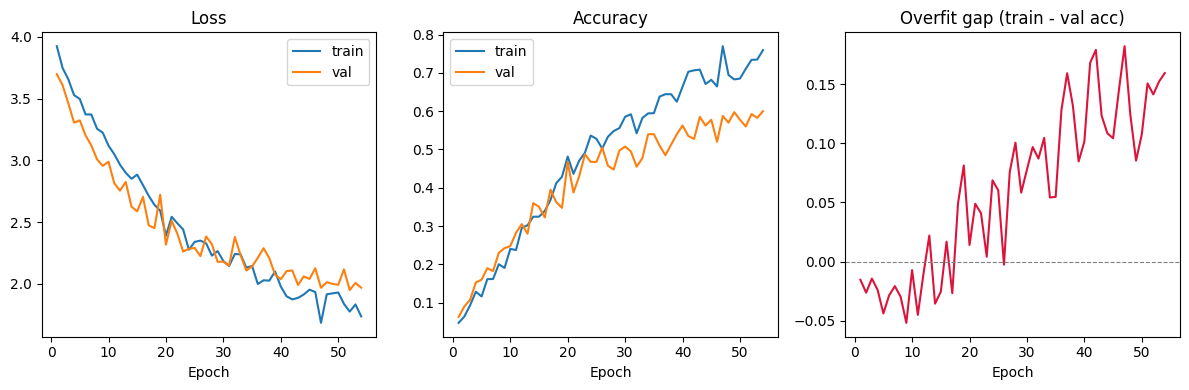

In [4]:
if history.get("train_loss"):
    plot_training_history(history)

Overall metrics:
  Accuracy=0.4825 | Precision(macro)=0.5192 | Recall(macro)=0.4825 | F1(macro)=0.4696
  Precision(weighted)=0.5192 | Recall(weighted)=0.4825 | F1(weighted)=0.4696

Per-class metrics (precision / recall / f1 / support):
  class 0: p=0.600, r=0.750, f1=0.667, n=8
  class 1: p=0.583, r=0.875, f1=0.700, n=8
  class 2: p=0.286, r=0.250, f1=0.267, n=8
  class 3: p=0.455, r=0.625, f1=0.526, n=8
  class 4: p=0.500, r=0.375, f1=0.429, n=8
  class 5: p=0.500, r=0.250, f1=0.333, n=8
  class 6: p=0.167, r=0.125, f1=0.143, n=8
  class 7: p=0.375, r=0.750, f1=0.500, n=8
  class 8: p=0.667, r=0.500, f1=0.571, n=8
  class 9: p=0.714, r=0.625, f1=0.667, n=8
  class 10: p=0.667, r=0.750, f1=0.706, n=8
  class 11: p=0.583, r=0.875, f1=0.700, n=8
  class 12: p=0.400, r=0.250, f1=0.308, n=8
  class 13: p=0.333, r=0.250, f1=0.286, n=8
  class 14: p=1.000, r=0.125, f1=0.222, n=8
  class 15: p=0.400, r=0.500, f1=0.444, n=8
  class 16: p=0.235, r=0.500, f1=0.320, n=8
  class 17: p=0.750, r=0.7

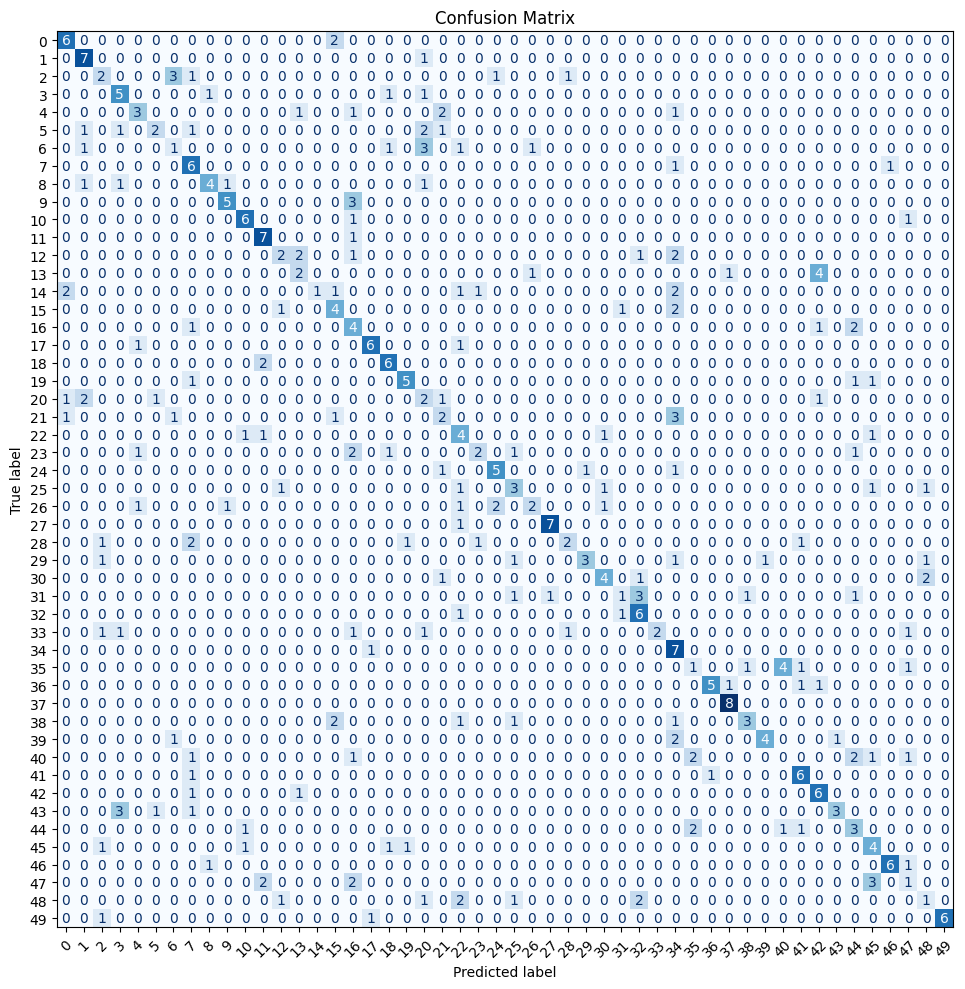

In [5]:
y_true, y_pred = trainer.predict_classifier(test_loader)
print_classification_metrics(y_true, y_pred)
plot_confusion_matrix(y_true, y_pred)